In [4]:
import os
os.listdir()

['.ipynb_checkpoints',
 'global-living-planet-index.csv',
 'living_planet_index_clean.csv',
 'Untitled.ipynb',
 'Untitled3.ipynb']

In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.style.use('seaborn-v0_8')

In [6]:
import os
os.getcwd()

'C:\\Users\\User\\Downloads\\living_planet_project'

In [7]:
import os
os.chdir(r"C:\Users\User\Downloads\living_planet_project")
os.getcwd()

'C:\\Users\\User\\Downloads\\living_planet_project'

In [8]:
df = pd.read_csv("global-living-planet-index.csv")
df.head()

,Entity,Code,Year,Living Planet Index,Upper confidence interval of Living Planet Index,Lower confidence interval of Living Planet Index
0,Africa,NaN,1970,100.000000,100.00000,100.000000
1,Africa,NaN,1971,94.004613,103.67786,86.478470
2,Africa,NaN,1972,89.996994,105.99841,77.636576
3,Africa,NaN,1973,89.674807,109.67456,74.525344
4,Africa,NaN,1974,85.613140,109.10656,67.872155


In [9]:
df = df.rename(columns={
    'Entity': 'Region',
    'Living Planet Index': 'LPI',
    'Upper confidence interval of Living Planet Index': 'LPI_upper',
    'Lower confidence interval of Living Planet Index': 'LPI_lower'
})
df.head()

,Region,Code,Year,LPI,LPI_upper,LPI_lower
0,Africa,NaN,1970,100.000000,100.00000,100.000000
1,Africa,NaN,1971,94.004613,103.67786,86.478470
2,Africa,NaN,1972,89.996994,105.99841,77.636576
3,Africa,NaN,1973,89.674807,109.67456,74.525344
4,Africa,NaN,1974,85.613140,109.10656,67.872155


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Region     357 non-null    object 
 1   Code       51 non-null     object 
 2   Year       357 non-null    int64  
 3   LPI        357 non-null    float64
 4   LPI_upper  357 non-null    float64
 5   LPI_lower  357 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 16.9+ KB


In [11]:
df['Year']= pd.to_numeric(df['Year'], errors='coerce').astype(int)
df['LPI']= pd.to_numeric(df['LPI'], errors='coerce')
df['LPI_upper']= pd.to_numeric(df['LPI_upper'], errors='coerce')
df['LPI_lower']= pd.to_numeric(df['LPI_lower'], errors='coerce')

In [12]:
df.isna().sum()

Region         0
Code         306
Year           0
LPI            0
LPI_upper      0
LPI_lower      0
dtype: int64

In [13]:
df=df.drop(columns=['Code'])
df.head()

,Region,Year,LPI,LPI_upper,LPI_lower
0,Africa,1970,100.000000,100.00000,100.000000
1,Africa,1971,94.004613,103.67786,86.478470
2,Africa,1972,89.996994,105.99841,77.636576
3,Africa,1973,89.674807,109.67456,74.525344
4,Africa,1974,85.613140,109.10656,67.872155


In [14]:
print(f"Regions ({df['Region'].nunique()}):")
print(df['Region'].unique())

print(f"\nYear range : {df['Year'].min()}-{df['Year'].max()}")

Regions (7):
['Africa' 'Asia and Pacific' 'Europe and Central Asia' 'Freshwater'
 'Latin America and the Caribbean' 'North America' 'World']

Year range : 1970-2020


In [15]:
df.to_csv("living_planet_index_clean.csv", index=False)

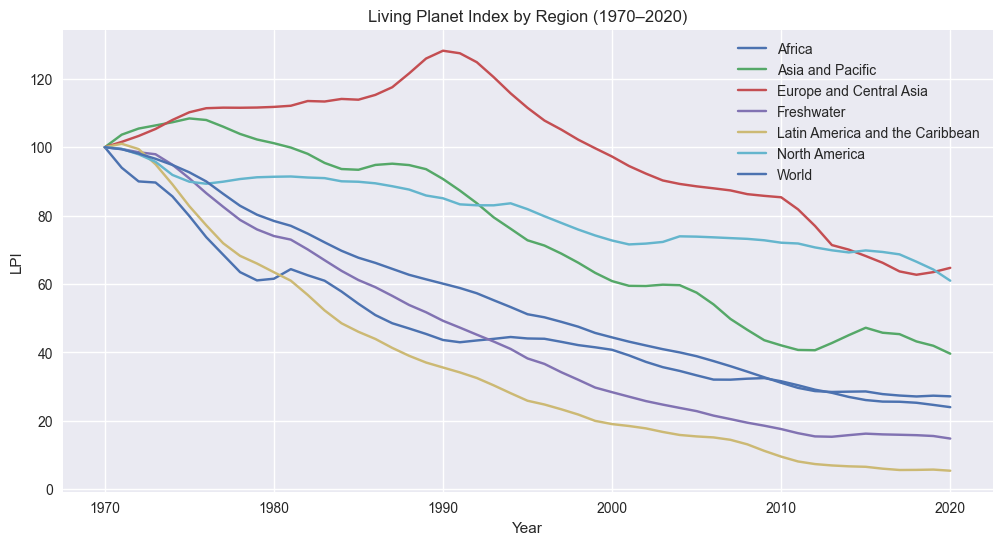

In [17]:
plt.figure(figsize=(12, 6))

for region in df['Region'].unique():
    sub = df[df['Region']== region]
    plt.plot(sub['Year'], sub['LPI'], label=region)
plt.title("Living Planet Index by Region (1970–2020)")
plt.xlabel("Year")
plt.ylabel("LPI")
plt.legend()
plt.grid(True)
plt.show()

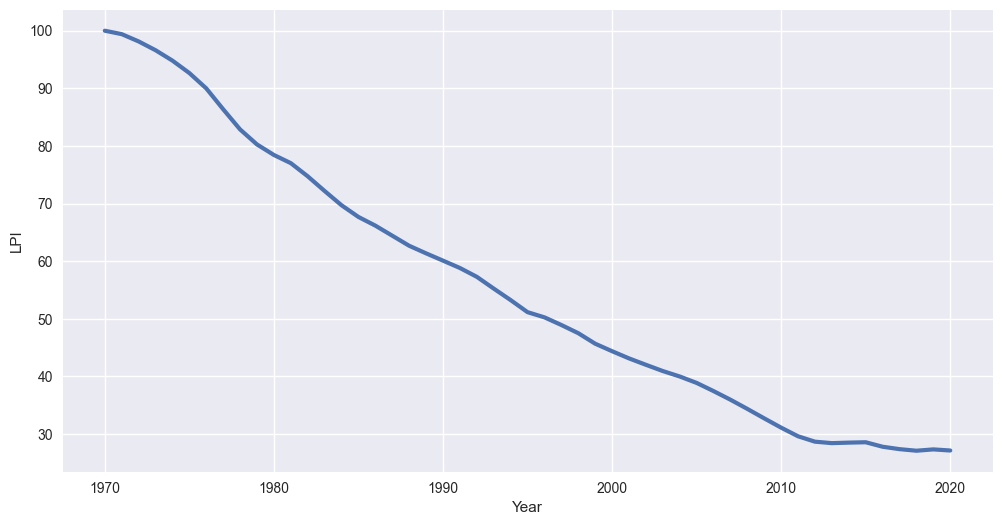

In [18]:
world=df[df['Region']== 'World']
plt.figure(figsize=(12,6))
plt.plot(world['Year'], world['LPI'], linewidth=3)
plt.xlabel("Year")
plt.ylabel("LPI")
plt.grid(True)
plt.show()

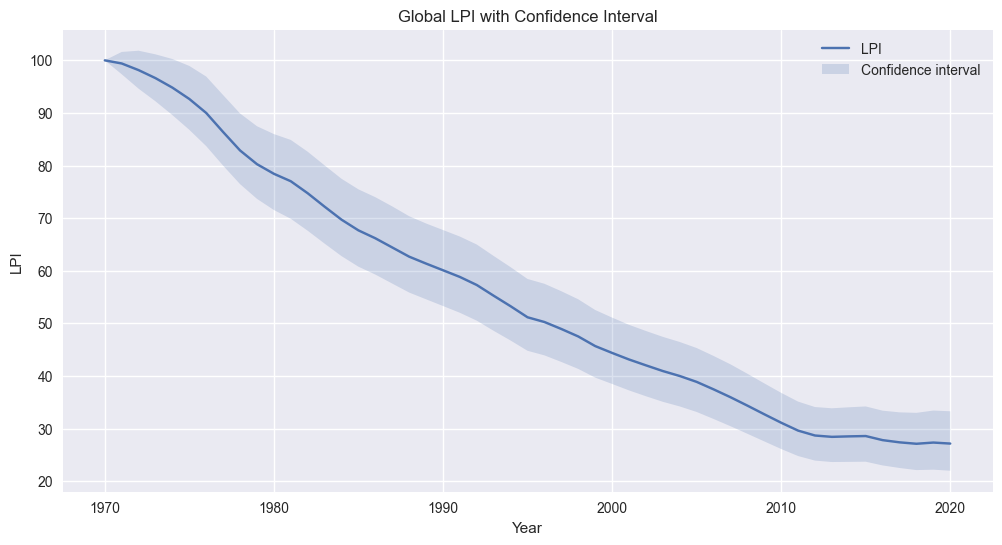

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(world['Year'], world['LPI'], label='LPI')

plt.fill_between(
    world['Year'],
    world['LPI_lower'],
    world['LPI_upper'],
    alpha=0.2,
    label='Confidence interval'
)

plt.title("Global LPI with Confidence Interval")
plt.xlabel("Year")
plt.ylabel("LPI")

plt.legend()
plt.grid(True)

plt.show()

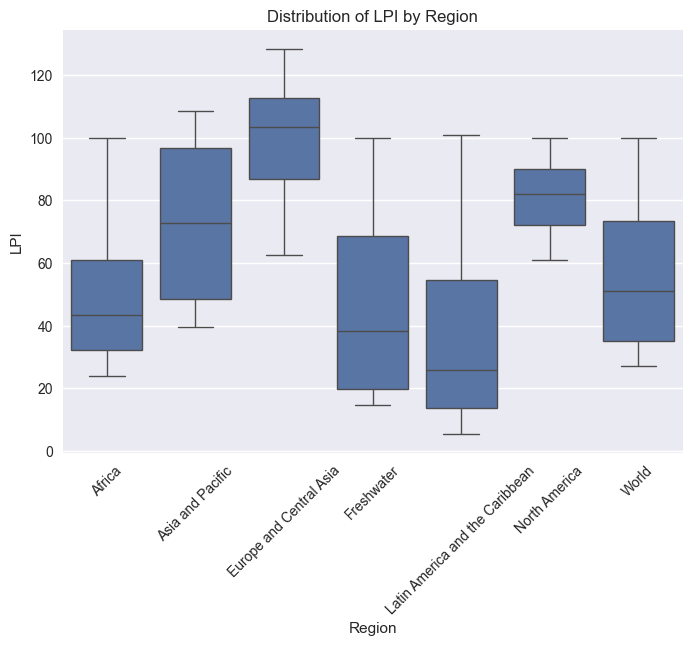

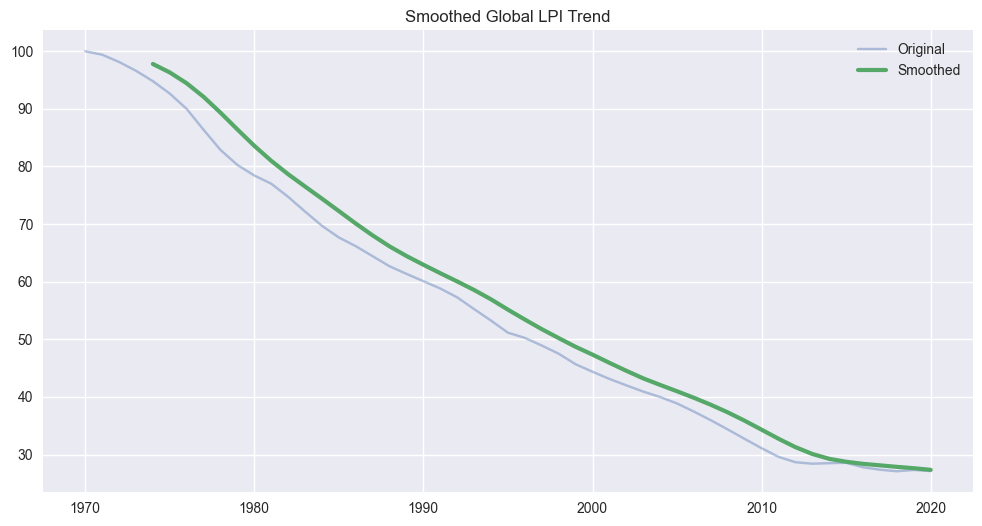

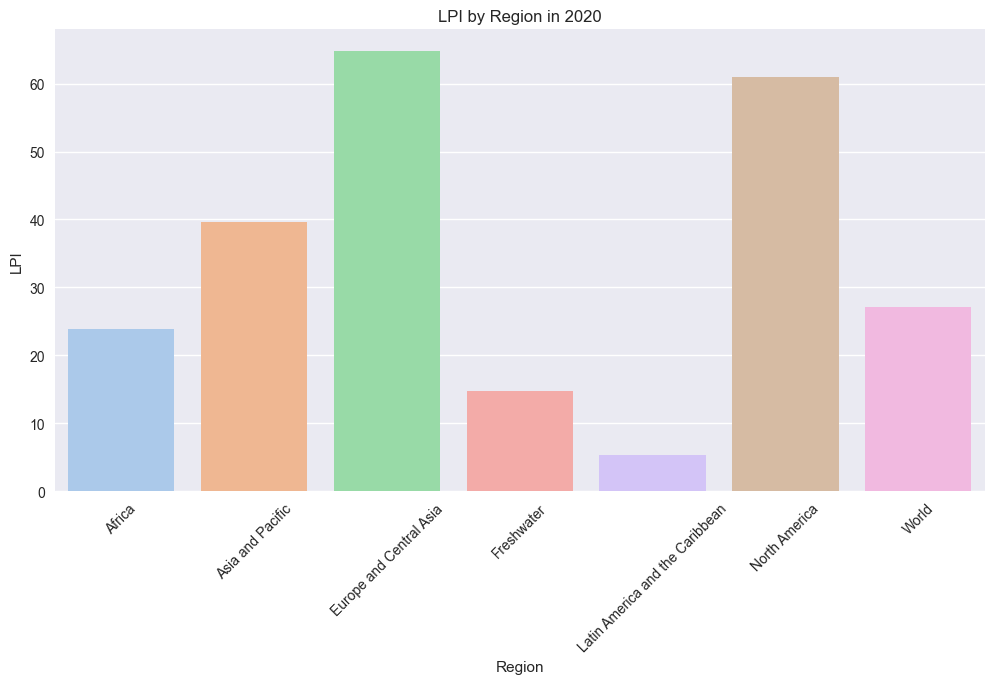

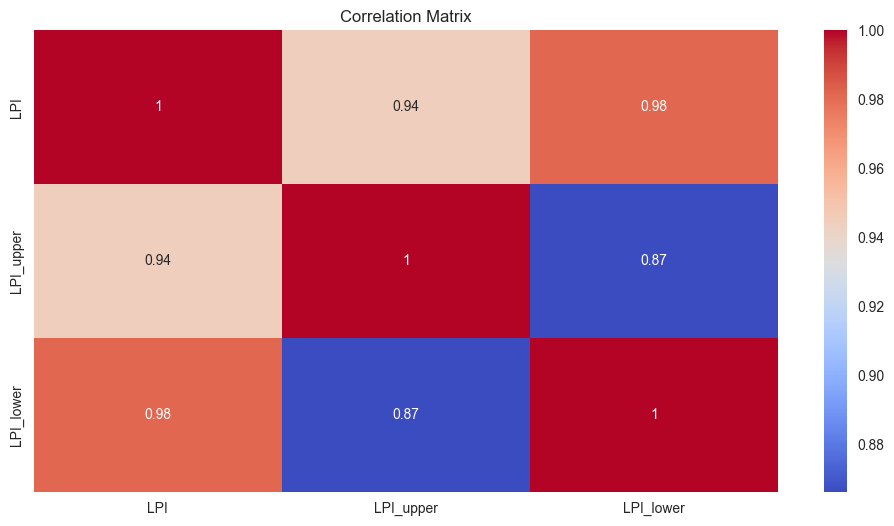

In [23]:
sns.boxplot(x='Region', y='LPI', data=df)
plt.title("Distribution of LPI by Region")
plt.xticks(rotation=45)
plt.show()

world = df[df['Region'] == 'World'].copy()

world['LPI_smooth']=world['LPI'].rolling(window=5).mean()

plt.figure(figsize=(12,6))
plt.plot(world['Year'], world['LPI'], alpha=0.4, label='Original')
plt.plot(world['Year'], world['LPI_smooth'], linewidth=3, label='Smoothed')
plt.legend()
plt.title("Smoothed Global LPI Trend")
plt.show()

latest=df[df['Year']==2020]
plt.figure(figsize=(12,6))
sns.barplot(x='Region', y='LPI', hue='Region', data=latest, palette='pastel')
plt.xticks(rotation=45)
plt.title("LPI by Region in 2020")
plt.show()

correlation=df[['LPI', 'LPI_upper', 'LPI_lower']].corr()

plt.figure(figsize=(12,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
